In [127]:
import numpy as np
import pandas as pd
%precision 3
#수시 합격자 자료
df_att1 = pd.read_csv("수시 컴퓨터과학과 출결(1,2,3학년 합산).csv") #출결
df_page1 = pd.read_csv("수시 컴퓨터과학과 생기부 장수.csv") #생기부 장 수
df_class1 = pd.read_csv("수시 컴퓨터과학과 국영수과 평균(1,2,3학년 합산).csv",encoding="cp949") #과목 별 등급
#정시 합격자 자료
df_att2 = pd.read_csv("정시 컴퓨터과학과 출결(1,2,3학년 합산).csv")
df_page2 = pd.read_csv("정시 컴퓨터과학과 생기부 장수.csv")

#수시 적합도 값
susi_compatibility = 0
#정시 적합도 값
jungsi_compatibility = 0

In [75]:
page1 = np.array(df_page1['수시 합격 학생 생기부 장수'])
page2 = np.array(df_page2['정시 합격 학생 생기부 장수'])
page_df = pd.DataFrame({
    '수시': page1,
    '정시': page2
})
page_df

,수시,정시
0,19,14
1,19,16
2,22,21
3,22,19
4,22,19
5,24,17
6,21,17
7,23,20
8,22,18
9,19,17


In [76]:
# 수시/정시 입학자들의 평균 생기부 페이지 수 
page_mean = page_df.mean()
# 페이지의 분산 & 표준편차
page_var = page_df.var()
page_std = page_df.std()

page1_result_df = pd.concat([
    page_mean.to_frame().T.rename(index={0: 'page_mean'}),
    page_var.to_frame().T.rename(index={0: 'page_var'}),
    page_std.to_frame().T.rename(index={0: 'page_std'}),
])
page1_result_df


,수시,정시
page_mean,21.615385,18.423077
page_var,5.926154,12.733846
page_std,2.434369,3.568452


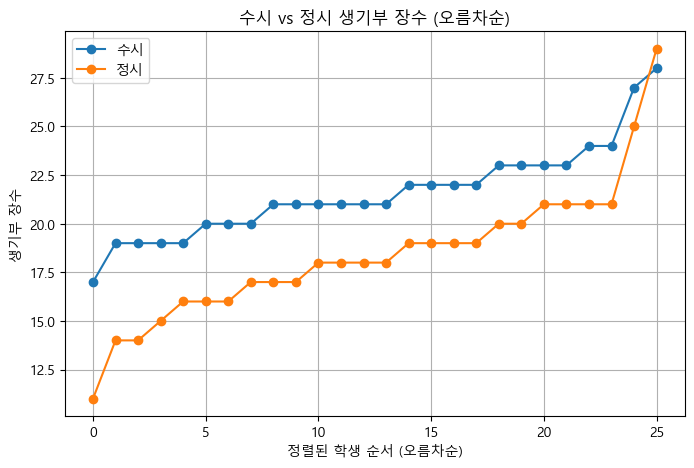

In [83]:
#수시와 정시 합격생들의 생기부 장수 오름차순으로 비교한 그래프
import matplotlib.pyplot as plt

page_sorted = pd.DataFrame({
    '수시': page_df['수시'].sort_values().reset_index(drop=True),
    '정시': page_df['정시'].sort_values().reset_index(drop=True)
})
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))

plt.plot(
    page_sorted.index,
    page_sorted['수시'],
    marker='o',
    label='수시'
)

plt.plot(
    page_sorted.index,
    page_sorted['정시'],
    marker='o',
    label='정시'
)
#x좌표 변수는 생기부 장수를 가진 학생 수가 아니라 0은 학생 0의 생기부 수 학생 25는 25번째 학생의 생기부 수를 뜻함
plt.xlabel('정렬된 학생 순서 (오름차순)')
plt.ylabel('생기부 장수')
plt.title('수시 vs 정시 생기부 장수 (오름차순)')
plt.legend()
plt.grid(True)

plt.show()

In [104]:
#수시 합격자들의 출결 평균, 분산,편차
att1_df = df_att1.sum().to_frame().T
att1_df.index = ['att_average']
att1_df = att1_df/27

att1_std = (df_att1 / 27).std().to_frame().T
att1_std.index = ['Std']

att1_var_df = (df_att1 / 27).var().to_frame().T
att1_var_df.index = ['Var']

att1_df = att1_df.round(2)
att1_std = att1_std.round(2)
att1_var_df = att1_var_df.round(2)
att1_df = pd.concat([att1_df, att1_std])
att1_df = pd.concat([att1_df, att1_var_df])
att1_df

,질병결석,미인정결석,기타결석,질병지각,미인정지각,기타지각,질병조퇴,미인정조퇴,기타조퇴,질병결과,미인정결과,기타결과
att_average,1.85,0.04,0.0,1.78,1.44,0.04,1.07,0.15,0.04,0.07,0.07,0.0
Std,0.11,0.01,0.0,0.09,0.12,0.01,0.05,0.02,0.01,0.01,0.01,0.0
Var,0.01,0.00,0.0,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.0


In [84]:
# 정시 합격자들의 출결 평균, 표준편차, 분산

att2_df = df_att2.sum().to_frame().T
att2_df.index = ['att_average']
att2_df = att2_df / 27

att2_std = (df_att2 / 27).std().to_frame().T
att2_std.index = ['Std']

att2_var_df = (df_att2 / 27).var().to_frame().T
att2_var_df.index = ['Var']

att2_df = att2_df.round(2)
att2_std = att2_std.round(2)
att2_var_df = att2_var_df.round(2)

att2_df = pd.concat([att2_df, att2_std])
att2_df = pd.concat([att2_df, att2_var_df])

att2_df

,질병결석,무단결석,기타결석,질병지각,무단지각,기타지각,질병조퇴,무단조퇴,기타조퇴,질병결과,무단결과,기타결과
att_average,1.22,0.52,0.0,2.70,3.07,0.04,1.93,0.0,0.0,0.11,0.30,0.0
Std,0.07,0.06,0.0,0.16,0.45,0.01,0.19,0.0,0.0,0.01,0.03,0.0
Var,0.00,0.00,0.0,0.03,0.20,0.00,0.04,0.0,0.0,0.00,0.00,0.0


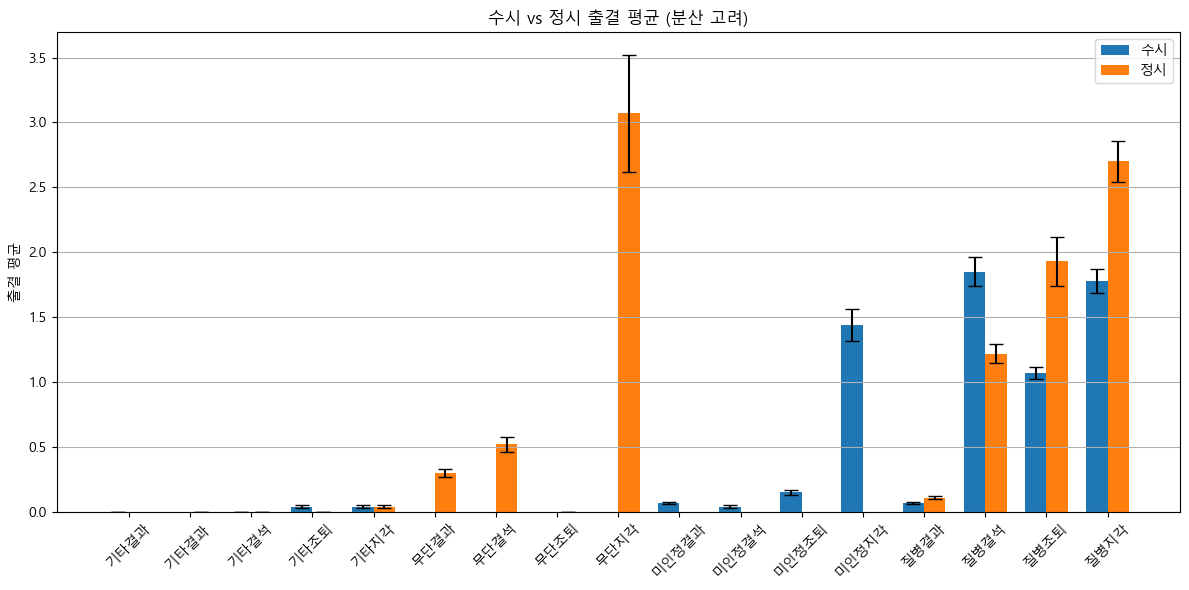

In [88]:
#막대 높이는 평균 출결이고 에러바의 길이는 변동성(분산의 크기)
#평균에 차이가 있고 에러바의 겹침이 적기에 전형간의 뚜렷한 차이가 보인다.

att_mean = pd.DataFrame({
    '수시': att1_df.loc['att_average'],
    '정시': att2_df.loc['att_average']
})

att_std = pd.DataFrame({
    '수시': att1_df.loc['Std'],
    '정시': att2_df.loc['Std']
})
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

x = np.arange(len(att_mean.index))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    att_mean['수시'],
    width,
    yerr=att_std['수시'],
    capsize=5,
    label='수시'
)

plt.bar(
    x + width/2,
    att_mean['정시'],
    width,
    yerr=att_std['정시'],
    capsize=5,
    label='정시'
)

plt.xticks(x, att_mean.index, rotation=45)
plt.ylabel('출결 평균')
plt.title('수시 vs 정시 출결 평균 (분산 고려)')
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [70]:
#수시 합격자들의 과목별 등급 평균, 분산, 편차
#분산 값이 작아 소수점 2자리 이상 표시를 하지 않음
class1_df = df_class1.sum().to_frame().T
class1_df.index = ['class_average']
class1_df = class1_df/27

class1_std = (df_class1 / 27).std().to_frame().T
class1_std.index = ['Std']

class1_var_df = (df_class1 / 27).var().to_frame().T
class1_var_df.index = ['Var']


class1_df = pd.concat([class1_df, class1_std])
class1_df = pd.concat([class1_df, class1_var_df])

class1_df

,국어,영어,수학,과학
class_average,3.322222,3.003704,2.855556,3.240741
Std,0.023617,0.036274,0.023887,0.027516
Var,0.000558,0.001316,0.000571,0.000757


In [121]:
#수시 합격자 기준을 통과하는 값을 랜덤으로 저장
new_student_page=int(np.random.normal(page_mean['수시'], page_std['수시']))
new_student_page_series = pd.Series(new_student_page, index=['수시'])

#정시 합격자를 기준으로하는 출결 값을 랜덤으로 저장
new_student_att_series = pd.Series(
    {
        col: np.random.choice(df_att2[col].dropna())
        if col in df_att2.columns else 0
        for col in recommended_att.index
    }
)
#수시 합격자를 기준으로 각 과목별 등급 값을 랜덤으로 저장
new_student_class_series = pd.Series(
    {col: np.random.choice(df_class1[col].dropna())
     for col in df_class1.columns}
)
new_student_page_series,new_student_att_series,new_student_class_series
#정시와 수시 합격자들의 값을 혼합시켜 이 프로그램의 예측성을 판단가능케할 수 있다.

(수시    19
 dtype: int64,
 질병결석     2
 미인정결석    0
 기타결석     0
 질병지각     7
 미인정지각    0
 기타지각     0
 질병조퇴     4
 미인정조퇴    0
 기타조퇴     0
 질병결과     0
 미인정결과    0
 기타결과     0
 dtype: int64,
 국어    3.7
 영어    2.0
 수학    3.2
 과학    2.7
 dtype: float64)

In [123]:
# 분산 보정 상수 중요도에 따라 차등으로 계수 보정
page_k = 0.8 #생기부 장수
att_weights = 1.2 #출결
class_weights = pd.Series({
    '국어': 1.3,
    '영어': 1.3,
    '수학': 1.6,
    '과학': 1.5
}) #등급

#각 종류 별 추천 점수 계산
recommended_page = page_mean['수시'] - page_k*page_var['수시']
recommended_att = (att1_df.loc['att_average'] - att_weights * att1_df.loc['Var'])
recommended_class = (class1_df.loc['class_average']- class_weights * class1_df.loc['Var'])

#비교: 학생 점수 vs 추천 점수
page_comparison = pd.DataFrame({
    'Recommended page': recommended_page,
    'Student page': new_student_page_series
})

att_comparison = pd.DataFrame({
    'Recommended att': recommended_att,
    'Student att': new_student_att_series
})

class_comparison = pd.DataFrame({
    'Recommended Class': recommended_class,
    'Student Class': new_student_class_series
})

att_comparison,page_comparison,class_comparison



(       Recommended att  Student att
 질병결석             1.838            2
 미인정결석            0.040            0
 기타결석             0.000            0
 질병지각             1.768            7
 미인정지각            1.428            0
 기타지각             0.040            0
 질병조퇴             1.070            4
 미인정조퇴            0.150            0
 기타조퇴             0.040            0
 질병결과             0.070            0
 미인정결과            0.070            0
 기타결과             0.000            0,
     Recommended page  Student page
 수시         16.874462            19,
     Recommended Class  Student Class
 국어           3.321497            3.7
 영어           3.001993            2.0
 수학           2.854643            3.2
 과학           3.239605            2.7)

In [129]:


susi_score = 0
jungsi_score = 0

#출결 값 비교해서 스코어 매긴 후 최종으로 출결에 따른 수시 정시 적합도 점수 책정
for col in recommended_att.index:
    if recommended_att[col] > new_student_att_series[col]:
        susi_score += 1
    else:
        jungsi_score += 1

if susi_score > jungsi_score:
    susi_compatibility +=1
else:
    jungsi_compatibility += 1
#생기부 값 비교해서  수시 정시 적합도 점수 책정
if recommended_page > new_student_page_series['수시']:
    jungsi_compatibility += 2
else:
    susi_compatibility += 2
#등급 값 비교해서 수시 정시 적합도 점수 책정
for col in recommended_class.index:
    if recommended_class[col] < new_student_class_series[col]:
        jungsi_compatibility += (3+class_weights[col])
    else:
       susi_compatibility += (3+class_weights[col])

if susi_compatibility > jungsi_compatibility:
    print("수시추천") 
elif susi_compatibility==jungsi_compatibility :
    print("중립")
else:
    print("정시추천")

수시추천


In [131]:
#세특에 자주나오는 유형의 키워드
keywords = [
    '탐구', '분석', '확장', '증명', '모델링',
    '함수', '미분', '적분', '극한',
    '문제해결', '논리적', '추론',
    '활용', '실생활', '연결',
    '심화', '자기주도', '발표', '보고서'
]
df = pd.read_csv('수시 컴퓨터과학과 미적분 세특.csv')

In [136]:
#수시 합격자 세특에서 키워드 반복 빈도 계산
from collections import Counter
import re

all_text = ' '.join(df['미적분 세특'].dropna())

words = re.findall('|'.join(keywords), all_text)
keyword_freq = Counter(words)

keyword_freq_df = pd.DataFrame(
    keyword_freq.items(),
    columns=['Keyword', 'Frequency']
).sort_values(by='Frequency', ascending=False)

keyword_freq_df

,Keyword,Frequency
2,적분,60
0,함수,45
5,미분,31
8,활용,30
11,탐구,20
4,발표,12
9,분석,9
12,보고서,5
6,증명,4
15,논리적,4


In [137]:
#새로운 미적분 세특
new_sepec = """
미적분 개념을 바탕으로 함수의 변화율을 분석하고
실생활 문제에 적용하는 탐구 활동을 수행함.
"""

In [138]:
new_score = 0
detail_score = {}

for kw in keywords:
    count = new_sepec.count(kw)
    if count > 0:
        weight = keyword_freq.get(kw, 1)  # 합격자에서 많이 나온 단어일수록 가중
        score = count * weight
        new_score += score
        detail_score[kw] = score

In [140]:
def calc_score(text):
    score = 0
    for kw in keywords:
        score += text.count(kw) * keyword_freq.get(kw, 1)
    return score

df['keyword_score'] = df['미적분 세특'].apply(calc_score)
threshold = df['keyword_score'].mean()

In [141]:
if new_score >= threshold:
    result = '✅ 수시 합격에 유리한 세특'
else:
    result = '⚠️ 수시 합격에 상대적으로 불리'

result

'⚠️ 수시 합격에 상대적으로 불리'